## Import Libraries

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import glob
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Dataset Loading

In [8]:
# Data Loading
class ImageDataset(Dataset):
    def __init__(self, photo_dir, monet_dir, transform=None):
        self.photo_images = sorted(glob.glob(os.path.join(photo_dir, '*.jpg')))
        self.monet_images = sorted(glob.glob(os.path.join(monet_dir, '*.jpg')))
        self.transform = transform

    def __len__(self):
        return len(self.photo_images)

    def __getitem__(self, idx):
        photo_img = Image.open(self.photo_images[idx]).convert('RGB')
        monet_img = Image.open(self.monet_images[idx % len(self.monet_images)]).convert('RGB')

        if self.transform:
            photo_img = self.transform(photo_img)
            monet_img = self.transform(monet_img)

        return photo_img, monet_img

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [9]:
# Create dataset
photo_ds_path = '/kaggle/input/styletransfer/data/photo'
monet_ds_path = '/kaggle/input/styletransfer/data/monet'
dataset = ImageDataset(photo_ds_path, monet_ds_path, transform)
dataloader = DataLoader(dataset, batch_size=6, shuffle=True)

## Exploratory Data Analysis (EDA)

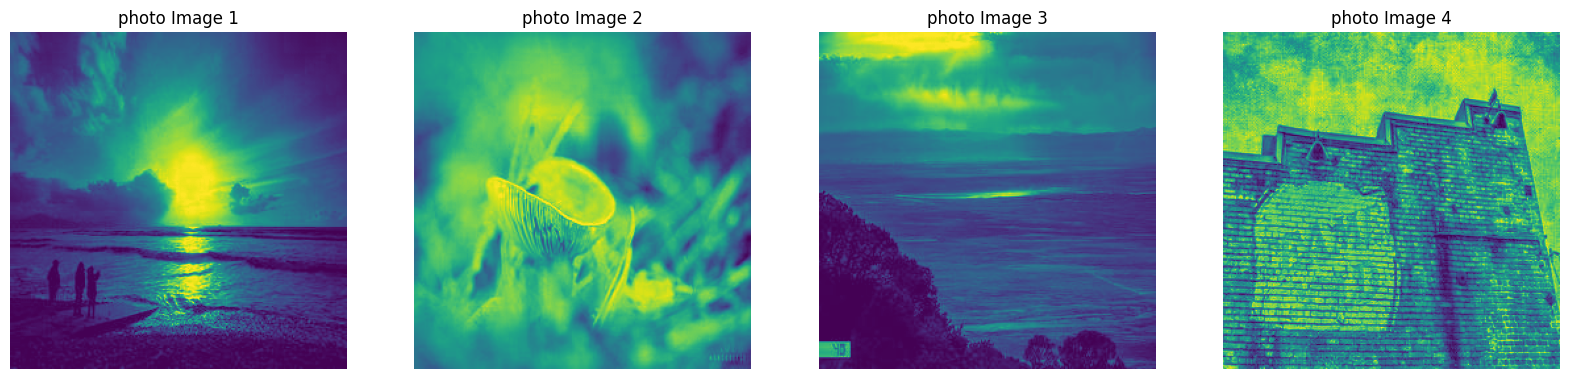

In [10]:
# Display a few images from the dataset in a single row
def show_samples(dataset, title):
    ds_iter = iter(dataset)
    plt.figure(figsize=(20, 8))  # Adjust the figure size for a single row of images
    for n_sample in range(4):
        example_sample = next(ds_iter)
        plt.subplot(1, 4, n_sample + 1)  # 1 row and 4 columns
        plt.title(f'{title} Image {n_sample + 1}')
        plt.imshow((example_sample[0][0] * 0.5) + 0.5)
        plt.axis('off')
    plt.show()

# Example usage
show_samples(dataset, 'photo')


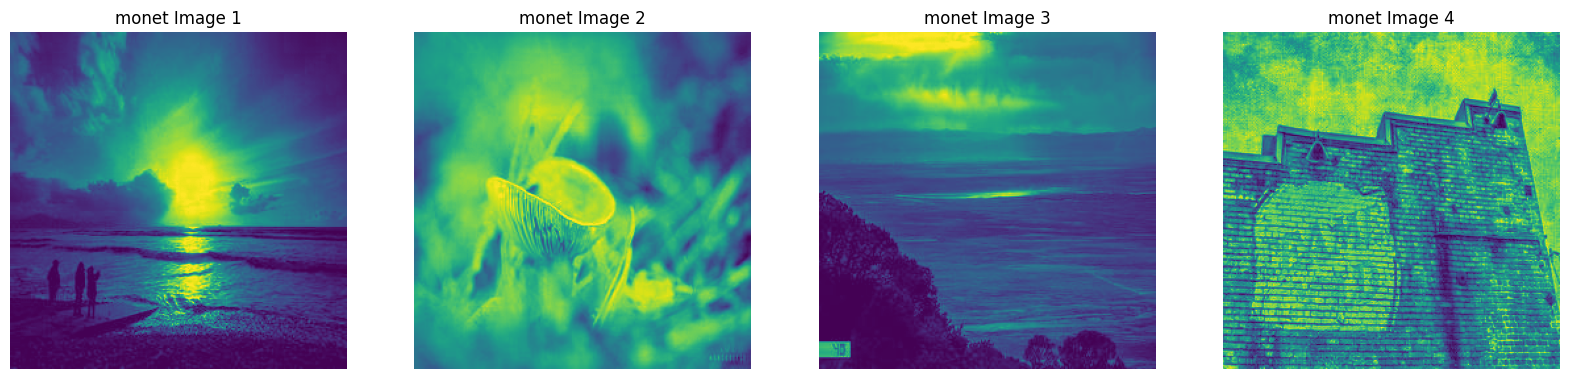

In [11]:
show_samples(dataset, 'monet')

## Model Architecture (CycleGAN)
building the generator and discriminator models as defined earlier using downsampling and upsampling blocks.

In [12]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=1, padding=3),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 3, 7, stride=1, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(256, 1, 4, stride=1, padding=1)
        )

    def forward(self, x):
        return self.main(x)

In [14]:
# Initialize Models
monet_generator = Generator().cuda()
photo_generator = Generator().cuda()
monet_discriminator = Discriminator().cuda()
photo_discriminator = Discriminator().cuda()

In [15]:
# # Loss Functions and Optimizers
criterion = nn.MSELoss()
optimizer_G = torch.optim.Adam(list(monet_generator.parameters()) + list(photo_generator.parameters()), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(list(monet_discriminator.parameters()) + list(photo_discriminator.parameters()), lr=2e-4, betas=(0.5, 0.999))

# # Adversarial Loss for CycleGAN (Binary Cross Entropy)
# criterion_adv = nn.BCEWithLogitsLoss()

# # Cycle Consistency Loss (L1 Loss)
# criterion_cycle = nn.L1Loss()

# # Optimizers
# optimizer_G = torch.optim.Adam(list(monet_generator.parameters()) + list(photo_generator.parameters()), lr=1e-4, betas=(0.5, 0.999))
# optimizer_D = torch.optim.Adam(list(monet_discriminator.parameters()) + list(photo_discriminator.parameters()), lr=1e-4, betas=(0.5, 0.999))


In [16]:
def train(dataloader, epochs, validation_loader=None):
    # Track the best models for both generator and discriminator
    best_loss_G = float('inf')
    best_epoch = 0

    for epoch in range(epochs):
        for real_photo, real_monet in dataloader:
            real_photo, real_monet = real_photo.cuda(), real_monet.cuda()

            # Train generators
            fake_monet = monet_generator(real_photo)
            fake_photo = photo_generator(real_monet)

          # Generator loss
            loss_G = criterion(monet_discriminator(fake_monet), torch.ones_like(monet_discriminator(fake_monet))) + \
                     criterion(photo_discriminator(fake_photo), torch.ones_like(photo_discriminator(fake_photo)))

            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()

           # Train discriminators
            loss_D_monet = criterion(monet_discriminator(real_monet), torch.ones_like(monet_discriminator(real_monet))) + \
                           criterion(monet_discriminator(fake_monet.detach()), torch.zeros_like(monet_discriminator(fake_monet)))

            loss_D_photo = criterion(photo_discriminator(real_photo), torch.ones_like(photo_discriminator(real_photo))) + \
                           criterion(photo_discriminator(fake_photo.detach()), torch.zeros_like(photo_discriminator(fake_photo)))

            optimizer_D.zero_grad()
            (loss_D_monet + loss_D_photo).backward()
            optimizer_D.step()

      # Save the best generator and discriminator models based on loss_G
        if loss_G.item() < best_loss_G:
            best_loss_G = loss_G.item()
            best_epoch = epoch
            # Save the best generator models
            torch.save(monet_generator.state_dict(), "best_monet_generator.pth")
            torch.save(photo_generator.state_dict(), "best_photo_generator.pth")
            # Save the corresponding discriminators
            torch.save(monet_discriminator.state_dict(), "best_monet_discriminator.pth")
            torch.save(photo_discriminator.state_dict(), "best_photo_discriminator.pth")

        print(f"Epoch [{epoch+1}/{epochs}], loss_G: {loss_G.item()}, loss_D: {loss_D_monet.item() + loss_D_photo.item()}")

    print(f"Best generator and discriminator models saved from epoch {best_epoch + 1} with loss_G: {best_loss_G:.4f}")

# def train(dataloader, epochs, validation_loader=None):
#     # Track the best models for both generator and discriminator
#     best_loss_G = float('inf')
#     best_epoch = 0

#     for epoch in range(epochs):
#         for real_photo, real_monet in dataloader:
#             real_photo, real_monet = real_photo.cuda(), real_monet.cuda()

#             # Train generators
#             fake_monet = monet_generator(real_photo)
#             fake_photo = photo_generator(real_monet)

#             # Adversarial loss for generator
#             loss_G_monet = criterion_adv(monet_discriminator(fake_monet), torch.ones_like(monet_discriminator(fake_monet)))
#             loss_G_photo = criterion_adv(photo_discriminator(fake_photo), torch.ones_like(photo_discriminator(fake_photo)))

            # # Cycle consistency loss
            # reconstructed_photo = photo_generator(fake_monet)
            # reconstructed_monet = monet_generator(fake_photo)
            # loss_cycle_monet = criterion_cycle(reconstructed_monet, real_monet)  # L1 loss
            # loss_cycle_photo = criterion_cycle(reconstructed_photo, real_photo)  # L1 loss

            # # Total generator loss (adversarial loss + cycle consistency loss)
            # loss_G = loss_G_monet + loss_G_photo + 10 * (loss_cycle_monet + loss_cycle_photo)

            # optimizer_G.zero_grad()
            # loss_G.backward()
            # optimizer_G.step()

            # # Train discriminators
            # loss_D_monet = criterion_adv(monet_discriminator(real_monet), torch.ones_like(monet_discriminator(real_monet))) + \
            #                criterion_adv(monet_discriminator(fake_monet.detach()), torch.zeros_like(monet_discriminator(fake_monet)))

            # loss_D_photo = criterion_adv(photo_discriminator(real_photo), torch.ones_like(photo_discriminator(real_photo))) + \
    #                        criterion_adv(photo_discriminator(fake_photo.detach()), torch.zeros_like(photo_discriminator(fake_photo)))

    #         optimizer_D.zero_grad()
    #         (loss_D_monet + loss_D_photo).backward()
    #         optimizer_D.step()

    #     # Save the best generator and discriminator models based on loss_G
    #     if loss_G.item() < best_loss_G:
    #         best_loss_G = loss_G.item()
    #         best_epoch = epoch
    #         # Save the best generator models
    #         torch.save(monet_generator.state_dict(), "best_monet_generator.pth")
    #         torch.save(photo_generator.state_dict(), "best_photo_generator.pth")
    #         # Save the corresponding discriminators
    #         torch.save(monet_discriminator.state_dict(), "best_monet_discriminator.pth")
    #         torch.save(photo_discriminator.state_dict(), "best_photo_discriminator.pth")

    #     print(f"Epoch [{epoch+1}/{epochs}], loss_G: {loss_G.item()}, loss_D: {loss_D_monet.item() + loss_D_photo.item()}")

    # print(f"Best generator and discriminator models saved from epoch {best_epoch + 1} with loss_G: {best_loss_G:.4f}")


## Training model

In [17]:
# Train model
train(dataloader, epochs=10)

Epoch [1/10], loss_G: 1.2275004386901855, loss_D: 0.3126887083053589
Epoch [2/10], loss_G: 1.2808820009231567, loss_D: 0.5793180763721466
Epoch [3/10], loss_G: 0.6915888786315918, loss_D: 0.8744444847106934
Epoch [4/10], loss_G: 1.2943124771118164, loss_D: 0.4180929660797119
Epoch [5/10], loss_G: 0.6947133541107178, loss_D: 0.7208723723888397
Epoch [6/10], loss_G: 1.0744482278823853, loss_D: 0.48091815412044525
Epoch [7/10], loss_G: 1.2650718688964844, loss_D: 0.5788178592920303
Epoch [8/10], loss_G: 1.0334010124206543, loss_D: 0.810565710067749
Epoch [9/10], loss_G: 1.005083441734314, loss_D: 0.6662740409374237
Epoch [10/10], loss_G: 0.7695045471191406, loss_D: 0.6224755942821503
Best generator and discriminator models saved from epoch 3 with loss_G: 0.6916


## Generate and Save Final Submission (images.zip)

In [19]:
import torch
import os
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
import glob
import shutil
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from scipy.linalg import sqrtm

# Define the Generator architecture - this should match the architecture of the saved model
class Generator(torch.nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = torch.nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=1, padding=3),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 3, 7, stride=1, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

# Initialize the Generator model
monet_generator = Generator().cuda()

# Load the state dictionary
monet_generator.load_state_dict(torch.load("/kaggle/working/best_monet_generator.pth"))
monet_generator.eval()

# Data transformation for inference
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Reverse normalization for converting back to the original image format
def reverse_normalize(tensor):
    return (tensor * 0.5 + 0.5) * 255

# Directory paths
photo_ds_path = '/kaggle/input/styletransfer/data/test_real'  # Path to the test photos
submission_dir = '/kaggle/working/submission_images'  # Folder where generated Monet images will be stored
os.makedirs(submission_dir, exist_ok=True)

# Load test photos
photo_files = sorted(glob.glob(os.path.join(photo_ds_path, '*.jpg')))
total_images = len(photo_files)

# Ensure at least 7k-10k images are generated
target_image_count = 400

# Function to extract features using InceptionV3
def extract_inception_features(image_batch, model, device):
    model.eval()
    image_batch = image_batch.to(device)
    with torch.no_grad():
        features = model(image_batch)  # Take output before classification layer
        features = features.view(features.size(0), -1)  # Flatten each feature vector to 1D
    return features.cpu().numpy()

# Load InceptionV3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False).cuda()
inception_model.fc = nn.Identity()  # Remove final classification layer for feature extraction

# Generate and save Monet-style images in batches, and calculate FID
batch_size = 5  # Adjust based on your GPU memory
generated_features = []
real_features = []

for batch_start in range(0, target_image_count, batch_size):
    batch_files = photo_files[batch_start:batch_start + batch_size]

    input_batch = []
    for photo_file in batch_files:
        try:
            img = Image.open(photo_file).convert('RGB')
            input_img = transform(img)
            input_batch.append(input_img)
        except Exception as e:
            print(f"Error loading image {photo_file}: {e}")
    
    # Check if input_batch is empty
    if len(input_batch) > 0:
        input_batch = torch.stack(input_batch).cuda()  # Stack into a batch and move to GPU
    else:
        print(f"Warning: Empty batch at index {batch_start}. Skipping batch.")
        continue

    with torch.no_grad():
        generated_batch = monet_generator(input_batch)

    generated_batch = generated_batch.cpu()  # Move back to CPU for saving

    # Save generated images with the same name as the input files
    for i, generated_img in enumerate(generated_batch):
        img_np = reverse_normalize(generated_img).byte().numpy().transpose(1, 2, 0)
        output_img = Image.fromarray(img_np)

        # Get the corresponding input photo file name (without the path and extension)
        original_filename = os.path.basename(batch_files[i])
        filename_without_extension = os.path.splitext(original_filename)[0]
        
        # Save the generated image with the same filename as the input photo
        output_img.save(os.path.join(submission_dir, f"{filename_without_extension}.jpg"))

    # Collect features for FID calculation (real and generated)
    real_batch = torch.stack([transform(Image.open(file).convert('RGB')).cuda() for file in batch_files])
    real_features.append(extract_inception_features(real_batch, inception_model, 'cuda'))

    generated_features.append(extract_inception_features(generated_batch, inception_model, 'cuda'))

    print(f"Processed batch {batch_start // batch_size + 1} / {(target_image_count + batch_size - 1) // batch_size}")

# Compute FID: Mean and Covariance
real_features = np.concatenate(real_features, axis=0)
generated_features = np.concatenate(generated_features, axis=0)

mu_r, sigma_r = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
mu_g, sigma_g = generated_features.mean(axis=0), np.cov(generated_features, rowvar=False)

# Check the shapes of the covariance matrices
print(f"Shape of sigma_r: {sigma_r.shape}")
print(f"Shape of sigma_g: {sigma_g.shape}")

# Ensure sigma_r and sigma_g are 2D matrices
if sigma_r.ndim != 2 or sigma_g.ndim != 2:
    raise ValueError("Covariance matrices must be 2D matrices.")

# Calculate FID: Mean and Covariance
diff = mu_r - mu_g

covmean = sqrtm(sigma_r.dot(sigma_g))

if np.iscomplexobj(covmean):
    covmean = covmean.real

fid = diff.dot(diff) + np.trace(sigma_r + sigma_g - 2 * covmean)

print(f"FID between real and generated images: {fid:.4f}")

# Zip the submission folder
shutil.make_archive('submission', 'zip', submission_dir)

print(f"Submission file 'submission.zip' created with generated Monet-style images.")


/tmp/ipykernel_31/919043188.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  monet_generator.load_state_dict(torch.load("/kaggle/working/best_monet_generator.pth"))


Processed batch 1 / 80
Processed batch 2 / 80
Processed batch 3 / 80
Processed batch 4 / 80
Processed batch 5 / 80
Processed batch 6 / 80
Processed batch 7 / 80
Processed batch 8 / 80
Processed batch 9 / 80
Processed batch 10 / 80
Processed batch 11 / 80
Processed batch 12 / 80
Processed batch 13 / 80
Processed batch 14 / 80
Processed batch 15 / 80
Processed batch 16 / 80
Processed batch 17 / 80
Processed batch 18 / 80
Processed batch 19 / 80
Processed batch 20 / 80
Processed batch 21 / 80
Processed batch 22 / 80
Processed batch 23 / 80
Processed batch 24 / 80
Processed batch 25 / 80
Processed batch 26 / 80
Processed batch 27 / 80
Processed batch 28 / 80
Processed batch 29 / 80
Processed batch 30 / 80
Processed batch 31 / 80
Processed batch 32 / 80
Processed batch 33 / 80
Processed batch 34 / 80
Processed batch 35 / 80
Processed batch 36 / 80
Processed batch 37 / 80
Processed batch 38 / 80
Processed batch 39 / 80
Processed batch 40 / 80
Processed batch 41 / 80
Processed batch 42 / 80
P

 Rough Work

In [ ]:
import shutil

# Remove everything inside /kaggle/working
working_dir = '/kaggle/working'
for file_name in os.listdir(working_dir):
    file_path = os.path.join(working_dir, file_name)
    if os.path.isdir(file_path):
        shutil.rmtree(file_path)
    else:
        os.remove(file_path)
